<a href="https://colab.research.google.com/github/kduran-stack/wildfire_cost_prediction/blob/main/wildfire_cost_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Goal: Using machine learning to predict future costs of wildfires and exporting the results to excel

#datasets

import pandas as pd
import numpy as np
import sklearn
import matplotlib as plt
import kagglehub
import os
!pip install zenodo-get
#downloads the entire record using its record ID.
!zenodo_get -r 14712845



INFO: Output directory: /content
INFO: Title: California Weather and Fire Prediction Dataset (1984–2025) with Engineered Features
INFO: Total size: 1.5 MB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.


In [ ]:
#loading in data

#dataset from Vivek Attri https://www.kaggle.com/datasets/vivekattri/california-wildfire-damage-2014-feb2025

#dataset info 2014-(feb)2025: Analyzing Property Loss, Financial Impact, and Causes Over the Past Decade.

path = kagglehub.dataset_download("vivekattri/california-wildfire-damage-2014-feb2025")
df = pd.read_csv(f"{path}/California Wildfire Damage.csv")
print("Path to dataset files:", path)
df = pd.read_csv(f"{path}/California Wildfire Damage.csv")


df.tail()
#note df is not organized by date


Using Colab cache for faster access to the 'california-wildfire-damage-2014-feb2025' dataset.
Path to dataset files: /kaggle/input/california-wildfire-damage-2014-feb2025


,Incident_ID,Date,Location,Area_Burned (Acres),Homes_Destroyed,Businesses_Destroyed,Vehicles_Damaged,Injuries,Fatalities,Estimated_Financial_Loss (Million $),Cause
95,INC1095,2018-01-16,Mendocino County,13112,1468,46,281,89,17,4008.58,Human Activity
96,INC1096,2022-07-07,Shasta County,39209,710,282,189,34,14,376.72,Human Activity
97,INC1097,2016-05-18,Shasta County,11863,702,9,40,100,1,1474.78,Human Activity
98,INC1098,2014-06-24,Napa Valley,1338,1619,262,293,94,3,3308.74,Human Activity
99,INC1099,2021-03-20,Mendocino County,44299,1217,172,176,81,20,4276.78,Human Activity


In [ ]:
# Zenedo file
#citation: Yavas, C. E., Kadlec, C., kim, J., & Chen, L. (2025). California Weather and Fire Prediction Dataset (1984–2025) with Engineered Features [Data set]. Zenodo. https://doi.org/10.5281/zenodo.14712845
#https://zenodo.org/records/14712845
df2 = pd.read_csv('CA_Weather_Fire_Dataset_1984-2025.csv')
df2.tail()

#end date is 1/12/2025




,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
14983,2025-01-08,0.0,73.0,53.0,10.51,False,2025,20.0,0.143973,1,Winter,0.0,6.485714,8
14984,2025-01-09,0.0,68.0,46.0,4.92,False,2025,22.0,0.072353,1,Winter,0.0,6.550000,9
14985,2025-01-10,0.0,70.0,46.0,3.58,False,2025,24.0,0.051143,1,Winter,0.0,6.327143,10
14986,2025-01-11,0.0,66.0,46.0,NaN,False,2025,20.0,NaN,1,Winter,0.0,6.561667,11
14987,2025-01-12,0.0,69.0,46.0,NaN,False,2025,23.0,NaN,1,Winter,0.0,7.068000,12


In [ ]:
#converting both datasets to be the same time

#note to self: notes on parameters in google doc notes

# Use 'mixed' to handle inconsistent date/time strings automatically
df['date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
df2['date'] = pd.to_datetime(df2['DATE'], format='mixed', errors='coerce')

#only matching on the day (removes hours/minutes)
df['date'] = df['date'].dt.normalize()
df2['date'] = df2['date'].dt.normalize()

# merge now that both 'date' columns are standardized
df_combined = pd.merge(df, df2, on='date', how='left')

#sorting by date and resetting indexes
#date sort
df_combined = df_combined.sort_values(by='date', ascending=True)
#index reset
df_combined = df_combined.reset_index(drop=True)
df_combined.head() #end date is 2023/12/08


,Incident_ID,Date,Location,Area_Burned (Acres),Homes_Destroyed,Businesses_Destroyed,Vehicles_Damaged,Injuries,Fatalities,Estimated_Financial_Loss (Million $),...,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,INC1058,2014-02-03,Santa Barbara County,47674,1186,438,71,54,11,2580.87,...,8.72,False,2014,14.0,0.145333,2,Winter,0.09,7.765714,34
1,INC1074,2014-03-04,Napa Valley,9737,1735,386,52,44,10,4075.67,...,5.82,False,2014,11.0,0.089538,3,Spring,2.91,7.445714,63
2,INC1038,2014-03-16,Mendocino County,41647,484,210,180,7,16,286.64,...,5.59,False,2014,27.0,0.067349,3,Spring,0.00,5.494286,75
3,INC1061,2014-03-28,Los Angeles County,11162,544,223,196,100,8,85.57,...,7.61,False,2014,14.0,0.113582,3,Spring,0.01,9.202857,87
4,INC1017,2014-04-16,Sonoma County,25094,1014,288,269,30,12,268.91,...,6.93,False,2014,9.0,0.103433,4,Spring,0.00,7.347143,106


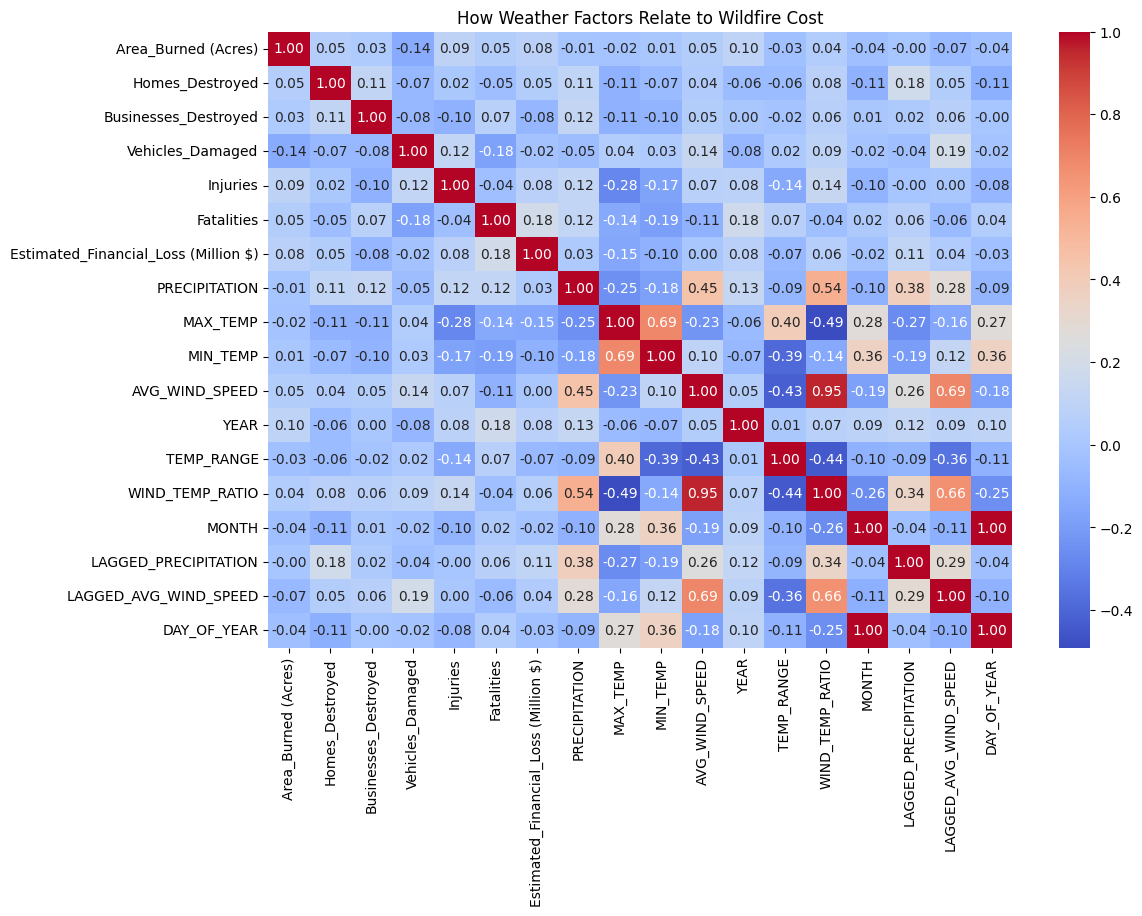

Incident_ID                             0
Date                                    0
Location                                0
Area_Burned (Acres)                     0
Homes_Destroyed                         0
Businesses_Destroyed                    0
Vehicles_Damaged                        0
Injuries                                0
Fatalities                              0
Estimated_Financial_Loss (Million $)    0
Cause                                   0
date                                    0
DATE                                    0
PRECIPITATION                           0
MAX_TEMP                                0
MIN_TEMP                                0
AVG_WIND_SPEED                          0
FIRE_START_DAY                          0
YEAR                                    0
TEMP_RANGE                              0
WIND_TEMP_RATIO                         0
MONTH                                   0
SEASON                                  0
LAGGED_PRECIPITATION              

KeyError: 'cost'

In [ ]:
#code suggestions come back later

#correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
# This looks at how every number relates to every other number (-1 to 1)

#simple sns.heatmap(df)
corr_matrix = df_combined.select_dtypes(include=['number']).corr()

# 2. Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("How Weather Factors Relate to Wildfire Cost")
plt.show()

#pick  x values that actually matter
# Quick check for missing data
print(df_combined.isnull().sum())

#setting up scikit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Define X (features) and y (target)
features = ['MAX_TEMP', 'AVG_WIND_SPEED', 'LAGGED_PRECIPITATION', 'WIND_TEMP_RATIO']
X = df_combined[features]
y = df_combined['cost'] # or whatever your cost column is named

# For time-series, we split manually by row index (e.g., 80% train, 20% test)
split_point = int(len(df_combined) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# Initialize and Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)



Key insights from the correlation map:

**Acreage and Damage**: There is a surprisingly low correlation (0.08) between Area_Burned and Estimated_Financial_Loss. This suggests that fire size alone is a poor predictor of economic impact.

**Primary Cost Drivers**: The strongest predictors of loss are Homes_Destroyed (0.18) and Injuries (0.12), indicating that financial risk is concentrated in the Wildland-Urban Interface (WUI).

**Investment Implications **: From a Private Equity perspective, the data suggests that startups focusing on Home Hardening and Structure Protection offer higher "avoided cost" returns than those focused solely on general suppression.

This data underscores the systemic risk to land and real estate valuations in fire-prone regions, where unpriced wildfire exposure can lead to sudden asset devaluation and increased insurance volatility.